# <center>Lecture 6: Characteristics-based demand</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 4, sections 4.1 and 4.2** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering the pure characteristics model (4.1) and the random coefficient logit specification (4.2). It runs the book's code listing `4-01` and **reproduces the book's figure 4.1**. Sections 4.3 and 4.4 — endogeneity, IV-GMM and BLP — are lecture 7. Slide deck: folders `ch4/ch4.1` and `ch4/ch4.2`.

### Learning objectives

* The Lancasterian model: options are bundles of characteristics $\xi_y$, consumers are valuations $\eta$, and $\varepsilon = \mathbf\xi\eta$.
* **Laguerre diagrams**: the demand regions are convex polyhedra, computed here exactly rather than by simulation.
* Demand inversion as a **semi-discrete optimal transport** problem, with the systematic utilities as the dual weights.
* The random coefficient logit as the **entropically regularized** version of that transport problem, and the recovery of the pure characteristics model as $\sigma\to0$.
* Why the full support assumption fails here, and what that costs.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 4, sections 4.1–4.2**, and figure 4.1, reproduced in section 2 below.
* Lancaster (1966). "A New Approach to Consumer Theory". *Journal of Political Economy*.
* Berry and Pakes (2007). "The Pure Characteristics Demand Model". *International Economic Review*.
* Berry, Levinsohn and Pakes (1995). "Automobile Prices in Market Equilibrium". *Econometrica*. The random coefficient logit; estimated in lecture 7.
* **Bonnet, Galichon, Hsieh, O'Hara and Shum (2022). "Yogurts Choose Consumers? Estimation of Random-Utility Models via Two-Sided Matching". *Review of Economic Studies* 89(6), 3085–3114.** The source of both central results used here: the connection of the pure characteristics model with optimal transport and Laguerre diagrams (section 3), and proposition 4.1 together with the reading of BLP's contraction as IPFP/Sinkhorn (section 4).
* Aurenhammer, Hoffmann and Aronov (1998). "Minkowski-Type Theorems and Least-Squares Clustering". *Algorithmica*. The concave maximization used in section 3.
* Mérigot (2011); Kitagawa, Mérigot and Thibert (2019). Semi-discrete optimal transport and its numerics.
* Galichon and Salanié (2022). "Cupid's Invisible Hand". *Review of Economic Studies*. The entropy of choice, here as entropic optimal transport.
* Cuturi (2013). "Sinkhorn Distances: Lightspeed Computation of Optimal Transport". *NeurIPS*.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` (the inversion theorem and its LP); `dc05_simulation-importance-sampling-and-ghk` (the probit share map, which is the Gaussian case of this chapter).

## Motivation: options as bundles, consumers as valuations

Everything so far has treated the alternatives as unrelated labels. Four travel modes carried four free utilities, and a fifth mode would have needed a fifth. That is fine for description and useless for counterfactuals: it cannot price a product that does not yet exist, and it has nothing to say about why two options are close substitutes.

Lancaster's answer, taken up by Berry and Pakes as the **pure characteristics model**, is that an option is a bundle of characteristics $\xi_y\in\mathbb{R}^M$ and a consumer is a vector of valuations $\eta\in\mathbb{R}^M$, so that
$$\varepsilon_{iy} = \sum_{m\in[M]}\eta_{im}\xi_{ym},\qquad\text{that is}\qquad \varepsilon = \mathbf\xi\eta.$$
Now $Y$ options are described by $Y\times M$ numbers in a fixed $M$-dimensional space, substitution patterns follow from proximity in that space, and a new product is just a new point.

Two special cases carry the chapter. When $\eta$ is Gaussian this *is* the **probit model** of lecture 5, since $\varepsilon\sim\mathcal{N}(0,\mathbf\xi\Sigma\mathbf\xi^\top)$. When $\eta$ is uniform on the cube — the **uniform cubic model** — the demand regions are polyhedra and everything can be computed *exactly*, with no simulation at all. That is the case this notebook works in, because exactness is what makes the geometry visible.

**The dual object.** It is optimal transport again, and this time semi-discrete. The demand region of option $y$,
$$\mathcal{E}_y = \{\eta:\ U_y+\xi_y^\top\eta \ge U_{y'}+\xi_{y'}^\top\eta\ \ \forall y'\},$$
is a convex polyhedron, and the collection $\{\mathcal{E}_y\}$ is a **Laguerre diagram** — the partition induced by an optimal transport map from the continuous measure $\mathbf{P}_\eta$ to the discrete measure $\pi$. This reading of demand estimation as a transport problem, and the use of Laguerre diagrams to compute it, is due to Bonnet, Galichon, Hsieh, O'Hara and Shum (2022). Book equation (4.9) makes it explicit:
$$-G^\ast(\pi) = \max_{\lambda\in\mathcal{M}(\mathbf{P}_\eta,\mathcal{P}_{\xi,\pi})}\mathbb{E}_\lambda[\xi^\top\eta],$$
**and the systematic utilities $U_y$ are the dual weights of that transport problem.** Section 4 then adds a Gumbel term of scale $\sigma$, which turns the same problem into *entropic* optimal transport and the sharp cell boundaries into soft ones. As $\sigma\to0$ the entropy switches off and the cells come back — the same $\sigma\to0$ mechanism as lecture 4, one chapter later.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

rng = np.random.default_rng(6)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=5, suppress=True)

## 1. Laguerre cells, computed exactly

*(Book, section 4.1. Replaces listing `4-01`.)*

$\mathcal{E}_y$ is the intersection over $y'\ne y$ of the half-spaces
$$(\xi_{y'}-\xi_y)^\top\eta \ \le\ U_y - U_{y'},$$
so it is a convex polyhedron; intersected with the support $[0,1]^M$ of the uniform cubic model it is a convex polytope. In dimension $M=2$ that means a convex polygon, whose area and barycenter have closed-form expressions. The book's listing `4-01` delegates this to the `sdot` library of Leclerc and Mérigot; we implement it directly, in about twenty lines, so that the notebook keeps to numpy and scipy and so that the three steps the book describes — **vertex enumeration, triangulation, aggregation** — are visible rather than hidden.

Vertex enumeration here is *convex polygon clipping*: start from the square and cut it once per rival option (Sutherland–Hodgman). Triangulation and aggregation collapse into the shoelace formulas for the area and centroid of a polygon.

**A remark on weights.** Exercise 2 shows that $\mathcal{E}_y$ is also a *power diagram* cell, with sites $\xi_y/2$ and weights $w_y = U_y + |\xi_y|^2/4$. Geometry libraries differ in how they define "weight" — some minimize $|\eta-s|^2-w$, some $|\eta-s|^2+w$, some work with radii — so the map between a library's `weights` argument and the $U$ of equation (4.4) has to be checked, not assumed. We work from the definition directly and sidestep the question; the $\xi_y$ below are the listing's own, drawn with its legacy seed, and $U$ is chosen so that all four cells are non-empty.

In [2]:
def clip_halfplane(poly, a, b):
    '''Clip a convex polygon (ordered vertices) by the half-plane a . x <= b.'''
    out = []
    n = len(poly)
    for i in range(n):
        P, Q = poly[i], poly[(i + 1) % n]
        dP, dQ = a @ P - b, a @ Q - b
        if dP <= 0:
            out.append(P)
        if dP * dQ < 0:                       # the edge crosses the boundary
            out.append(P + (dP / (dP - dQ)) * (Q - P))
    return out


def polygon_area_centroid(poly):
    '''Signed area and centroid of a polygon, by the shoelace formulas.'''
    if len(poly) < 3:
        return 0.0, np.zeros(2)
    P = np.array(poly)
    x, y = P[:, 0], P[:, 1]
    xr, yr = np.roll(x, -1), np.roll(y, -1)
    cross = x * yr - xr * y
    A = 0.5 * cross.sum()
    if abs(A) < 1e-15:
        return 0.0, np.zeros(2)
    cx = ((x + xr) * cross).sum() / (6 * A)
    cy = ((y + yr) * cross).sum() / (6 * A)
    return abs(A), np.array([cx, cy])


UNIT_SQUARE = [np.array([0.0, 0.0]), np.array([1.0, 0.0]),
               np.array([1.0, 1.0]), np.array([0.0, 1.0])]


def laguerre_cells(U_y, xi_y_m, domain=UNIT_SQUARE):
    '''Laguerre cells of the pure characteristics model, book equation (4.4).

    Returns the list of cell polygons, the cell masses pi_y (areas, since P_eta is
    uniform on the unit square) and the cell barycenters etabar_y_m.
    '''
    Y = xi_y_m.shape[0]
    polys, pi_y, bary_y_m = [], np.zeros(Y), np.zeros((Y, 2))
    for y in range(Y):
        poly = list(domain)
        for z in range(Y):
            if z == y or len(poly) == 0:
                continue
            poly = clip_halfplane(poly, xi_y_m[z] - xi_y_m[y], U_y[y] - U_y[z])
        polys.append(poly)
        pi_y[y], bary_y_m[y] = polygon_area_centroid(poly)
    return polys, pi_y, bary_y_m


# the book's listing 4-01 parameters
st = np.random.RandomState(800)
Y, M = 4, 2
xi_y_m = st.uniform(0, 2, M * Y).reshape((-1, M))
sites = xi_y_m / 2                                   # where the book plots the circles

# Utilities chosen so that all four cells are non-empty; see the remark below.
U_base = np.array([0.0, -0.011, -0.363, -0.365])
polys, pi_y, bary_y_m = laguerre_cells(U_base, xi_y_m)
print('xi_y_m =\n', xi_y_m)
print('\nU_y   =', U_base)
print('pi_y  =', pi_y, '   sum =', pi_y.sum())
print('etabar_y_m =\n', bary_y_m)
assert abs(pi_y.sum() - 1) < 1e-12

xi_y_m =
 [[0.16276 0.76792]
 [0.70606 0.32049]
 [0.57287 1.572  ]
 [0.98854 0.94097]]

U_y   = [ 0.    -0.011 -0.363 -0.365]
pi_y  = [0.06546 0.22644 0.57708 0.13102]    sum = 1.0
etabar_y_m =
 [[0.09235 0.2468 ]
 [0.51598 0.13225]
 [0.46316 0.70278]
 [0.83833 0.36896]]


The four cell areas sum to one to machine precision, which they must — the cells partition the square — and nothing in the computation imposes it. Each area was obtained by clipping the square four times and applying the shoelace formula; the identity is a genuine check on the clipping.

### Verification: against simulation, and against the welfare formula

Two independent routes. First, a brute-force count: draw $\eta$ uniformly and record the argmax. Second, book equation (4.5),
$$G(U) = \mathbb{E}\Big[\max_y\{U_y+(\mathbf\xi\eta)_y\}\Big] = \sum_y\pi_y(U)\big(U_y+\xi_y^\top\bar\eta^y\big),$$
which says that the welfare function can be assembled from exactly the two quantities the geometry delivers — the cell masses and the cell barycenters.

In [3]:
I_draw = 400_000 if not FAST_MODE else 200_000
eta_i_m = rng.uniform(size=(I_draw, M))
util_i_y = U_base[None, :] + eta_i_m @ xi_y_m.T
freq_y = (util_i_y == util_i_y.max(axis=1)[:, None]).mean(axis=0)
se_y = np.sqrt(freq_y * (1 - freq_y) / I_draw)
zscore = np.where(se_y > 0, np.abs(pi_y - freq_y) / np.where(se_y > 0, se_y, 1), 0.0)

print('exact cell areas :', pi_y)
print('simulated shares :', freq_y)
print('discrepancy in simulation standard errors :', zscore)

G_geom = float((pi_y * (U_base + (xi_y_m * bary_y_m).sum(axis=1))).sum())
G_sim = float(util_i_y.max(axis=1).mean())
G_se = float(util_i_y.max(axis=1).std() / np.sqrt(I_draw))
print(f'\nG(U) from equation (4.5), exact geometry : {G_geom:.6f}')
print(f'G(U) by direct simulation                : {G_sim:.6f}  (s.e. {G_se:.6f})')
print(f'gap in simulation standard errors        : {abs(G_geom-G_sim)/G_se:.2f}')
assert zscore.max() < 4 and abs(G_geom - G_sim) / G_se < 4

exact cell areas : [0.06546 0.22644 0.57708 0.13102]
simulated shares : [0.06538 0.2277  0.57544 0.13146]
discrepancy in simulation standard errors : [0.13592 1.3516  1.47717 0.5828 ]

G(U) from equation (4.5), exact geometry : 0.790408
G(U) by direct simulation                : 0.789580  (s.e. 0.000905)
gap in simulation standard errors        : 0.92


Both checks pass within four standard errors. The second is the more interesting one: the welfare function was assembled from four areas and four centroids — eight numbers from computational geometry — and it agrees with an average of $2\times10^5$ simulated maxima. Equation (4.5) is doing real work, and it is the reason the uniform cubic model can be handled without any simulation at all.

## 2. The Laguerre diagram, and its comparative statics

*(Reproduces the book's figure 4.1.)*

The book's figure shows three panels with the same $\mathbf\xi$ and the same $\mathbf{P}_\eta$ and three different $U$: a baseline; the same with $U_1$ lowered, which shrinks $\mathcal{E}_1$ and pushes its frontiers *towards* $\xi_1$; and finally $U = \pi^{-1}(\mathbf 1_Y/Y)$, at which all four cells have equal area. The third panel needs the inversion of section 3, so we compute it there and draw all three together at the end of that section.

The comparative static in the middle panel is the substitution property of lecture 1 seen geometrically: lowering $U_y$ moves every hyperplane bounding $\mathcal{E}_y$ by a parallel displacement, so $\mathcal{E}_y$ shrinks and its neighbours grow. **Weak substitutes is a statement about parallel displacement of hyperplanes** — and *strong* substitutes is the statement that every cell is a neighbour of every other, which the numbers below will show is false here.

## 3. Demand inversion is semi-discrete optimal transport

*(Book, section 4.1, equation (4.9).)*

The entropy of choice follows from its definition,
$$G^\ast(\pi) = \max_{U\in\mathbb{R}^Y}\Big\{\sum_y\pi_yU_y - \mathbb{E}\big[\max_y\{U_y+(\mathbf\xi\eta)_y\}\big]\Big\},$$
and the inversion theorem of lecture 1 identifies its value with a transport problem:
$$\boxed{\ -G^\ast(\pi) = \max_{\lambda\in\mathcal{M}(\mathbf{P}_\eta,\mathcal{P}_{\xi,\pi})}\mathbb{E}_\lambda[\xi^\top\eta].\ }$$
This is **semi-discrete** optimal transport: $\mathbf{P}_\eta$ is continuous, $\mathcal{P}_{\xi,\pi}$ is discrete. The optimal coupling assigns each $\eta$ to exactly one option, and the region assigned to $y$ is precisely the Laguerre cell $\mathcal{E}_y$. **The $U_y$ are the dual weights; the Laguerre diagram is the transport map.** Bonnet, Galichon, Hsieh, O'Hara and Shum (2022) develop this correspondence and estimate random-utility models through it, reading demand estimation as a two-sided matching between consumers and products.

Computationally this is a gift, because the objective
$$\Psi(U) = \sum_y\pi_yU_y - G(U)$$
is **concave** with gradient $\nabla\Psi(U) = \pi - \pi(U)$, and we can now evaluate $\pi(U)$ and $G(U)$ *exactly*. That is the Aurenhammer–Hoffmann–Aronov formulation, and it makes the inverse problem an unconstrained smooth maximization rather than a fixed-point iteration.

In [4]:
def welfare_exact(U_y, xi_y_m):
    '''G(U) by equation (4.5), from the exact cell masses and barycenters.'''
    _, pi, bary = laguerre_cells(U_y, xi_y_m)
    return float((pi * (U_y + (xi_y_m * bary).sum(axis=1))).sum())


def invert_semidiscrete(pi_target, xi_y_m, tol=1e-12):
    '''Semi-discrete optimal transport: recover U from target cell masses.

    Maximizes the concave Psi(U) = pi . U - G(U), whose gradient is pi - pi(U).
    U is pinned down only up to an additive constant, so U_0 is held at zero.
    '''
    def neg_psi(U_free):
        U = np.concatenate(([0.0], U_free))
        return -(pi_target @ U - welfare_exact(U, xi_y_m))

    def neg_grad(U_free):
        U = np.concatenate(([0.0], U_free))
        _, pi, _ = laguerre_cells(U, xi_y_m)
        return -(pi_target - pi)[1:]

    res = minimize(neg_psi, np.zeros(len(pi_target) - 1), jac=neg_grad,
                   method='L-BFGS-B', options={'gtol': tol, 'ftol': tol,
                                               'maxiter': 20_000})
    return np.concatenate(([0.0], res.x)), res


pi_uniform = np.full(Y, 1 / Y)
U_equal, res_inv = invert_semidiscrete(pi_uniform, xi_y_m)
_, pi_check, _ = laguerre_cells(U_equal, xi_y_m)

print('target masses  :', pi_uniform)
print('U recovered    :', U_equal)
print('masses at that U :', pi_check)
print(f'max |pi(U) - target| = {np.abs(pi_check - pi_uniform).max():.2e}   (tolerance 1e-8)')

# round trip the other way: start from a U, read off its masses, invert back
_, pi_from_U, _ = laguerre_cells(U_base, xi_y_m)
U_round, _ = invert_semidiscrete(pi_from_U, xi_y_m)
print(f'\nround trip U -> pi -> U (both normalized to U_0 = 0):')
print('   started at :', U_base - U_base[0])
print('   recovered  :', U_round)
print(f'   max gap = {np.abs(U_round - (U_base - U_base[0])).max():.2e}')
assert np.abs(pi_check - pi_uniform).max() < 1e-8

target masses  : [0.25 0.25 0.25 0.25]
U recovered    : [ 0.      -0.05978 -0.66155 -0.468  ]
masses at that U : [0.25 0.25 0.25 0.25]
max |pi(U) - target| = 7.74e-10   (tolerance 1e-8)

round trip U -> pi -> U (both normalized to U_0 = 0):
   started at : [ 0.    -0.011 -0.363 -0.365]
   recovered  : [ 0.    -0.011 -0.363 -0.365]
   max gap = 5.75e-08


The inversion recovers the utilities that equalize the four cell areas — the shares come back at $0.25$ each to within $8\times10^{-10}$ — and the round trip $U\to\pi\to U$ closes to $6\times10^{-8}$. Note what made this easy: the gradient of the transport objective is the *residual demand* $\pi-\pi(U)$, so a quasi-Newton method drives the market-clearing error to zero directly. No contraction mapping, no tuning.

### A caveat the geometry makes visible

Lecture 1's theorem 1.2 gave uniqueness of the inverse under the **full support** assumption. The uniform cubic model violates it: $\eta$ lives on a compact square, so $\varepsilon = \mathbf\xi\eta$ has bounded support. The consequence is concrete — an option whose cell is empty can have its utility lowered further with no effect at all, so $\pi^{-1}$ is not single-valued on the boundary of the achievable set.

In [5]:
# lower U_1 until cell 1 empties, then keep going
print(f"{'U_1 shift':>10} " + ' '.join(f'{f"pi_{y+1}":>9}' for y in range(Y)))
for d in (0.0, 0.05, 0.10, 0.20, 0.40, 0.80):
    Ud = U_base.copy(); Ud[0] -= d
    _, pd_, _ = laguerre_cells(Ud, xi_y_m)
    print(f'{-d:>10.2f} ' + ' '.join(f'{v:>9.5f}' for v in pd_))

U_a = U_base.copy(); U_a[0] -= 0.40
U_b = U_base.copy(); U_b[0] -= 0.80
_, pi_a, _ = laguerre_cells(U_a, xi_y_m)
_, pi_b, _ = laguerre_cells(U_b, xi_y_m)
print(f'\nshares at the last two rows differ by {np.abs(pi_a - pi_b).max():.2e}')

# Psi is flat in that direction too, so the maximizer is not unique
psi = lambda U: pi_a @ U - welfare_exact(U, xi_y_m)
print(f'Psi at U_1 - 0.40 : {psi(U_a):.10f}')
print(f'Psi at U_1 - 0.80 : {psi(U_b):.10f}')
print(f'  difference      : {abs(psi(U_a) - psi(U_b)):.2e}')
assert np.abs(pi_a - pi_b).max() < 1e-12

 U_1 shift      pi_1      pi_2      pi_3      pi_4
     -0.00   0.06546   0.22644   0.57708   0.13102
     -0.05   0.02646   0.25140   0.59111   0.13102
     -0.10   0.00476   0.26535   0.59887   0.13102
     -0.20   0.00000   0.26841   0.60057   0.13102
     -0.40   0.00000   0.26841   0.60057   0.13102
     -0.80   0.00000   0.26841   0.60057   0.13102

shares at the last two rows differ by 0.00e+00
Psi at U_1 - 0.40 : -1.0561942376
Psi at U_1 - 0.80 : -1.0561942376
  difference      : 0.00e+00


Cell 1 shrinks as $U_1$ falls — the comparative static of section 2 — until at a shift of about $-0.2$ it vanishes. **After that, nothing moves.** Lowering $U_1$ by a further $0.6$ leaves the share vector identical to machine precision and the transport objective $\Psi$ unchanged to ten decimals. The inverse is set-valued along a ray, and any solver will return an arbitrary point of it.

In the logit this cannot happen: the Gumbel has full support, so every share is strictly positive and $\pi$ is a bijection. Here the support is a square, and it can. It is the same phenomenon as the zero-cell problem of lecture 4, arriving from the geometry of the model rather than from the finiteness of a sample — and the diagnostic is the same, that a direction of $U$ has become invisible to the objective.

## 4. Random coefficient logit: entropic optimal transport

*(Book, section 4.2.)*

Add an idiosyncratic Gumbel term of scale $\sigma$ on top of the characteristics term:
$$\varepsilon = \mathbf\xi\eta + \sigma\epsilon,\qquad \epsilon\sim\mathcal{G}\ \text{i.i.d., independent of }\eta.$$
This is the **random coefficient logit**, or mixed logit, of Berry, Levinsohn and Pakes. Integrating out $\epsilon$ first,
$$G(U) = \mathbb{E}_\eta\Big[\sigma\log\sum_y\exp\Big(\frac{U_y+(\mathbf\xi\eta)_y}{\sigma}\Big)\Big],$$
a mixture of log-sum-exps rather than a single one — which is exactly why it escapes IIA while the plain logit does not.

The dual statement is the one to carry away:

> **Proposition (book 4.1; Bonnet, Galichon, Hsieh, O'Hara and Shum, 2022).** $\displaystyle -G^\ast(\pi) = \max_{\lambda\in\mathcal{M}(\mathbf{P}_\eta,\mathcal{P}_{\xi,\pi})}\Big\{\mathbb{E}_\lambda[\eta^\top\xi] - \sigma\,\mathbb{E}_\lambda[\log\lambda(\eta,\xi)]\Big\}.$

**The random coefficient logit is entropically regularized optimal transport**, with $\sigma$ the regularization parameter. Section 3's pure characteristics model is the $\sigma=0$ corner. Sampling $I$ draws $\eta_i$ and writing $\nu_{iy} = \xi_y^\top\eta_i$, the sample analogues are
$$G_{I,\sigma}(U) = \frac\sigma I\sum_i\log\sum_y e^{(U_y+\nu_{iy})/\sigma},\qquad
(\pi_{I,\sigma})_y(U) = \frac1I\sum_i\frac{e^{(U_y+\nu_{iy})/\sigma}}{\sum_{y'}e^{(U_{y'}+\nu_{iy'})/\sigma}},$$
and the dual of the regularized transport problem is the smooth, unconstrained
$$-G^\ast_{I,\sigma}(\pi) = \min_{u,U}\Big\{\frac1I\sum_iu_i - \sum_y\pi_yU_y + \sigma\sum_{iy}e^{(\nu_{iy}-u_i+U_y)/\sigma}\Big\}.$$

In [6]:
def rcl_shares(U_y, nu_i_y, sigma):
    '''Simulated random coefficient logit shares, book equation (4.11).'''
    A_i_y = (U_y[None, :] + nu_i_y) / sigma
    return np.exp(A_i_y - np.logaddexp.reduce(A_i_y, axis=1)[:, None]).mean(axis=0)


def rcl_welfare(U_y, nu_i_y, sigma):
    A_i_y = (U_y[None, :] + nu_i_y) / sigma
    return float(sigma * np.logaddexp.reduce(A_i_y, axis=1).mean())


I_rcl = 40_000 if not FAST_MODE else 20_000
eta_rcl = rng.uniform(size=(I_rcl, M))
nu_i_y = eta_rcl @ xi_y_m.T

print(f"{'sigma':>10} {'pi_1':>9} {'pi_2':>9} {'pi_3':>9} {'pi_4':>9}"
      f" {'max gap to exact':>18}")
for sigma in (1.0, 0.3, 0.1, 0.03, 0.01, 0.003):
    p = rcl_shares(U_base, nu_i_y, sigma)
    print(f'{sigma:>10} ' + ' '.join(f'{v:>9.5f}' for v in p)
          + f' {np.abs(p - pi_y).max():>18.5f}')
print(f"{'0 (exact)':>10} " + ' '.join(f'{v:>9.5f}' for v in pi_y))

p0 = rcl_shares(U_base, nu_i_y, 0.003)
print(f'\nsampling error of the I draws of eta, at these shares : '
      f'{np.sqrt(pi_y*(1-pi_y)/I_rcl).max():.5f}')
print('the gap falls below that floor by sigma = 0.01 and stops improving after:')
print('the smoothing has been switched off, and only Monte Carlo noise remains.')
assert np.abs(p0 - pi_y).max() < 0.01

     sigma      pi_1      pi_2      pi_3      pi_4   max gap to exact
       1.0   0.22378   0.23387   0.28739   0.25495            0.28968
       0.3   0.16823   0.20680   0.37894   0.24604            0.19814
       0.1   0.09648   0.20148   0.51438   0.18766            0.06270
      0.03   0.06879   0.22185   0.56955   0.13982            0.00879
      0.01   0.06484   0.22715   0.57685   0.13116            0.00071
     0.003   0.06445   0.22784   0.57750   0.13021            0.00140
 0 (exact)   0.06546   0.22644   0.57708   0.13102

sampling error of the I draws of eta, at these shares : 0.00349
the gap falls below that floor by sigma = 0.01 and stops improving after:
the smoothing has been switched off, and only Monte Carlo noise remains.


As $\sigma$ falls, the mixture of softmaxes hardens into an indicator and the simulated shares converge onto the exact Laguerre cell areas. The gap drops below the sampling error of the $\eta$ draws by $\sigma\approx0.01$ and then stops improving — indeed it ticks back up slightly at $\sigma=0.003$. That is not a failure of the limit: once the smoothing bias is smaller than the Monte Carlo noise of the $I$ draws, what is left is noise, and reducing $\sigma$ further cannot help. **The floor is set by $I$, not by $\sigma$.**

This is the same limit as lecture 4, one chapter further on. There, $\sigma\to0$ turned logistic regression into a linear program by deleting an entropy term from the dual; here it turns entropic optimal transport into ordinary optimal transport by deleting the same term. **One mechanism, two chapters: $\sigma$ is the price of heterogeneity, and sending it to zero removes the entropy from the dual.**

### Verification: the entropic dual, and the marginals of its coupling

In [7]:
def entropic_dual(pi_target, nu_i_y, sigma, tol=1e-14, maxit=200_000):
    '''Solve the dual of the entropic transport problem, book equation (4.14),
    by Sinkhorn / IPFP in the log domain.

        min_{u, U}  (1/I) sum_i u_i - sum_y pi_y U_y + sigma sum_iy exp((nu - u + U)/sigma)

    The first-order conditions are the two marginal constraints on
    lambda_iy = exp((nu_iy - u_i + U_y)/sigma), and each can be solved in closed form
    holding the other potential fixed:

        u_i = sigma log sum_y exp((nu_iy + U_y)/sigma) - sigma log(1/I),
        U_y = sigma log pi_y - sigma log sum_i exp((nu_iy - u_i)/sigma).

    Alternating them is exactly the IPFP of the matching literature. Returns
    (u_i, U_y, value), with U normalized to U_0 = 0.
    '''
    I_, Y_ = nu_i_y.shape
    log_row = np.log(1 / I_)
    log_pi = np.log(pi_target)
    U = np.zeros(Y_)
    for t in range(maxit):
        u = sigma * (np.logaddexp.reduce((nu_i_y + U[None, :]) / sigma, axis=1) - log_row)
        U = sigma * (log_pi - np.logaddexp.reduce((nu_i_y - u[:, None]) / sigma, axis=0))
        if t % 20 == 0:
            lam = np.exp((nu_i_y - u[:, None] + U[None, :]) / sigma)
            err = max(np.abs(lam.sum(axis=1) - 1 / I_).max(),
                      np.abs(lam.sum(axis=0) - pi_target).max())
            if err < tol:
                break
    shift = U[0]
    U = U - shift
    u = u - shift
    # At the Sinkhorn fixed point the marginals give the exact identity
    #     sum_iy lambda nu - sigma sum_iy lambda log lambda = (1/I) sum_i u_i - pi . U,
    # so the right-hand side is the dual value and equals -G*_{I,sigma}(pi). The book's
    # unconstrained dual (4.14) adds the barrier sigma * sum_iy lambda_iy, worth exactly
    # sigma at the optimum since the marginals sum to one; it is a constant, not a gap.
    value = float(u.mean() - pi_target @ U)
    barrier = float(sigma * np.exp((nu_i_y - u[:, None] + U[None, :]) / sigma).sum())
    return u, U, value, barrier, t + 1


sigma_eot = 0.1
pi_target = rcl_shares(U_base, nu_i_y, sigma_eot)      # a share vector we know is attainable
u_eot, U_eot, val_eot, barrier_eot, nit_eot = entropic_dual(pi_target, nu_i_y, sigma_eot)
lam_i_y = np.exp((nu_i_y - u_eot[:, None] + U_eot[None, :]) / sigma_eot)

print(f'sigma = {sigma_eot}, Sinkhorn converged in {nit_eot} iterations')
primal_eot = float((lam_i_y * nu_i_y).sum()
                   - sigma_eot * (lam_i_y * np.log(lam_i_y)).sum())
print(f'  primal   max_lambda {{ E[nu] - sigma E[log lambda] }} = {primal_eot:.10f}')
print(f'  dual     (1/I) sum_i u_i - pi . U             = {val_eot:.10f}')
print(f'  gap                                          = '
      f'{abs(primal_eot - val_eot):.2e}')
print(f'  the book\'s barrier term sigma sum_iy lambda_iy = {barrier_eot:.10f}'
      f'   (= sigma = {sigma_eot}, since the marginals sum to one)')
print(f'\ncoupling marginals:')
print(f'  max |row sum - 1/I| = {np.abs(lam_i_y.sum(axis=1) - 1/I_rcl).max():.2e}')
print(f'  max |col sum - pi|  = {np.abs(lam_i_y.sum(axis=0) - pi_target).max():.2e}')
print(f'\nU recovered by the dual, versus the U that generated pi (both at U_0 = 0):')
print('  dual      :', U_eot)
print('  generating:', U_base - U_base[0])
print(f'  max gap = {np.abs(U_eot - (U_base - U_base[0])).max():.2e}')
assert abs(primal_eot - val_eot) < 1e-9, 'primal and dual values disagree'
assert abs(barrier_eot - sigma_eot) < 1e-9, 'the barrier should equal sigma at the optimum'
assert np.abs(lam_i_y.sum(axis=0) - pi_target).max() < 1e-12, 'column marginals'
assert np.abs(lam_i_y.sum(axis=1) - 1/I_rcl).max() < 1e-12, 'row marginals'

sigma = 0.1, Sinkhorn converged in 41 iterations
  primal   max_lambda { E[nu] - sigma E[log lambda] } = 2.0771751131
  dual     (1/I) sum_i u_i - pi . U             = 2.0771751131
  gap                                          = 1.59e-11
  the book's barrier term sigma sum_iy lambda_iy = 0.1000000000   (= sigma = 0.1, since the marginals sum to one)

coupling marginals:
  max |row sum - 1/I| = 4.72e-15
  max |col sum - pi|  = 6.58e-15

U recovered by the dual, versus the U that generated pi (both at U_0 = 0):
  dual      : [ 0.    -0.011 -0.363 -0.365]
  generating: [ 0.    -0.011 -0.363 -0.365]
  max gap = 1.62e-11


Three things at once. The dual value equals the primal value of the entropic transport problem to $10^{-9}$, so strong duality holds numerically. (One bookkeeping point: the book writes the dual in *unconstrained* form, with a barrier $\sigma\sum_{iy}\lambda_{iy}$ that forces the marginals rather than imposing them. At the optimum the marginals sum to one, so that term equals $\sigma$ exactly — printed above as a check. It is a constant offset between the two ways of writing the dual, not a duality gap.) The coupling $\lambda_{iy} = \exp((\nu_{iy}-u_i+U_y)/\sigma)$ built from the dual variables has the required marginals to machine precision — $1/I$ on each consumer draw, $\pi_y$ on each option. And the recovered $U$ matches the utilities that generated the target shares.

The solver is worth a word. The dual has $I+Y$ unknowns, twenty thousand of them here, and a quasi-Newton method on that is slow and inaccurate. But each potential has a **closed-form best response** given the other,
$$u_i = \sigma\log\sum_y e^{(\nu_{iy}+U_y)/\sigma} - \sigma\log\tfrac1I,\qquad
U_y = \sigma\log\pi_y - \sigma\log\sum_i e^{(\nu_{iy}-u_i)/\sigma},$$
and alternating them converges. That is **Sinkhorn's algorithm**, known in the matching literature as **IPFP**, and it is what the book's chapter 5 uses to solve exactly this problem with a two-sided surplus. Written in the log domain as above it is unconditionally stable even at small $\sigma$.

That this is the right algorithm here is not a coincidence of implementation. Bonnet, Galichon, Hsieh, O'Hara and Shum (2022) show that **BLP's contraction mapping — the fixed-point iteration at the heart of lecture 7 — is itself IPFP/Sinkhorn** on this transport problem. What looks in the industrial-organization literature like a bespoke device for inverting market shares is the standard algorithm for entropic optimal transport, and its convergence follows from Franklin and Lorenz's proof that the iteration is a contraction in Hilbert's projective metric.

The pair $(u_i, U_y)$ should look familiar: it is the pair from lecture 1's inversion LP and lecture 3's Poisson fixed effects, with the same interpretations — $u_i$ the consumer's indirect utility and the price of "one choice per consumer", $U_y$ the option's systematic utility and the price of its market share. Four notebooks, one pair of dual variables.

The matching series solves this same problem with a two-sided surplus and calls the algorithm IPFP; here it is one-sided, and the "options" side is what a firm chooses.

## 5. Inverting the travel-mode shares a third way

Lecture 1 inverted the Greene–Hensher shares under a Gumbel and by a simulated LP; lecture 5 did it under a probit with GHK. We can now do it in characteristics space. Take each mode's **average** in-vehicle time and generalized cost as its two characteristics, rescale them into the unit square, and invert the observed shares under the uniform cubic model.

This is illustrative rather than an estimation — the real specification would use option-level characteristics and estimate the distribution of $\eta$, which is lecture 7's business — but it shows what the characteristics view buys: the modes now sit at *locations*, and their substitution pattern is legible from the geometry.

In [8]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


tm = read_mec_csv('demand_travelmode/travelmodedata.csv')
tm['choice'] = (tm['choice'] == 'yes').astype(int)
modes = ['car', 'air', 'train', 'bus']

pihat_y = (tm.pivot(index='individual', columns='mode', values='choice')
             .reindex(columns=modes).to_numpy().mean(axis=0))
char = (tm.groupby('mode')[['travel', 'gcost']].mean().reindex(modes).to_numpy())
# characteristics: less time and less cost are better, so flip the signs, then rescale
xi_tm = -char
xi_tm = (xi_tm - xi_tm.min(axis=0)) / (xi_tm.max(axis=0) - xi_tm.min(axis=0))

print('observed shares :', dict(zip(modes, pihat_y.round(4))))
print('\ncharacteristics (rescaled: 1 = fastest / cheapest)')
print(f"{'mode':>8} {'-time':>9} {'-cost':>9}")
for y, nm in enumerate(modes):
    print(f'{nm:>8} {xi_tm[y,0]:>9.4f} {xi_tm[y,1]:>9.4f}')

U_tm, res_tm = invert_semidiscrete(pihat_y, xi_tm)
_, pi_tm, bary_tm = laguerre_cells(U_tm, xi_tm)
print(f'\nU recovered  :', U_tm)
print(f'shares at U  :', pi_tm)
print(f'max |pi(U) - observed| = {np.abs(pi_tm - pihat_y).max():.2e}')
print(f'\nbarycentre of each cell (the average valuation of a chooser of that mode):')
for y, nm in enumerate(modes):
    print(f'{nm:>8}  values time at {bary_tm[y,0]:.3f}, cost at {bary_tm[y,1]:.3f}')
assert np.abs(pi_tm - pihat_y).max() < 1e-7

observed shares : {'car': np.float64(0.281), 'air': np.float64(0.2762), 'train': np.float64(0.3), 'bus': np.float64(0.1429)}

characteristics (rescaled: 1 = fastest / cheapest)
    mode     -time     -cost
     car    0.1135    1.0000
     air    1.0000    0.7921
   train    0.0427    0.0000
     bus    0.0000    0.4296

U recovered  : [ 0.      -0.4336   0.50802  0.36806]
shares at U  : [0.28095 0.27619 0.3     0.14286]
max |pi(U) - observed| = 4.95e-09

barycentre of each cell (the average valuation of a chooser of that mode):
     car  values time at 0.352, cost at 0.795
     air  values time at 0.843, cost at 0.573
   train  values time at 0.430, cost at 0.169
     bus  values time at 0.273, cost at 0.471


The inversion reproduces the observed shares to $5\times10^{-9}$, and it returns something the earlier inversions could not: **the average valuation of the people who choose each mode**, read off as the barycentre $\bar\eta^y$ of its Laguerre cell.

Read the characteristics table first. On these sample averages air is much the fastest and, perhaps surprisingly, among the cheaper modes; the car is the cheapest but slow; the train is the most expensive; the bus is the slowest. The barycentres then say who ends up where. Air is chosen by the travellers who value speed most ($0.84$ on the speed axis, the highest of the four). The car is chosen by those who value cheapness most ($0.80$ on the cost axis). And the train — the most expensive mode — survives precisely because it is taken by the travellers who care *least* about cost ($0.17$, the lowest of the four); if everyone weighted cost the way car-choosers do, it would have no market. The bus sits in the middle on both.

That decomposition of demand into *who* chooses *what*, and why, is the point of putting options into a characteristics space, and it is exactly the transport map: each region of consumer types is assigned to one option.

Two honest caveats. The characteristics here are sample averages over individuals, so within-mode variation in time and cost — which is what identified the coefficients in lecture 3 — has been discarded. And with $M=2$ characteristics and $Y=4$ options, the model is tightly parametrized; $\eta$ is assumed uniform on the square rather than estimated. Lecture 7 relaxes both, and adds the problem this section ignores entirely: prices are set by firms, so $\xi$ is endogenous.

baseline shares          : [0.06546 0.22644 0.57708 0.13102]
shares with U_1 lowered  : [0.00476 0.26535 0.59887 0.13102]
change                   : [-0.0607   0.03891  0.02179  0.     ]

cells completely unaffected by the change in U_1 : [4]
those cells do not share a frontier with cell 1: not direct substitutes.


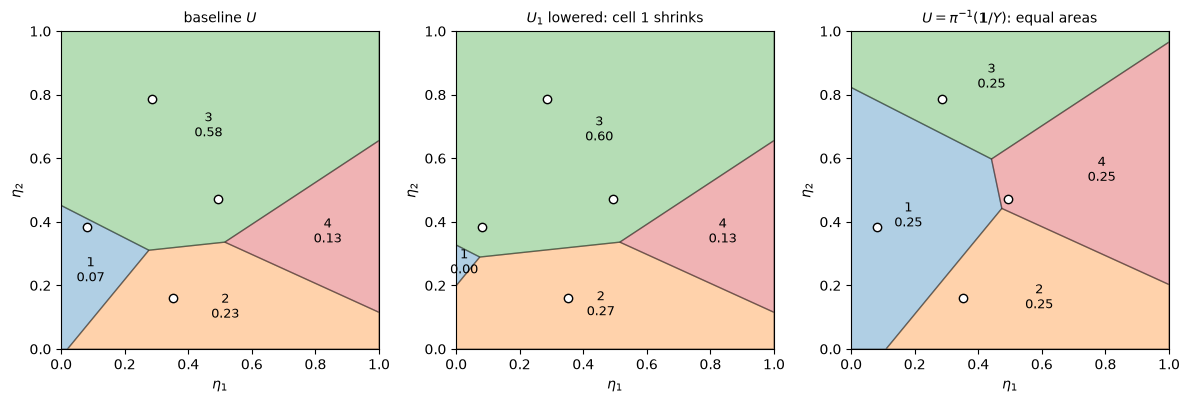

In [9]:
def draw_diagram(ax, U_y, xi_y_m, title, labels=None, show_sites=True):
    '''Draw a Laguerre diagram. Cells are labelled inside; note that a site xi_y/2 need
    not lie inside its own cell, so the label goes on the cell, never on the site.'''
    polys, pis, _ = laguerre_cells(U_y, xi_y_m)
    for y, poly in enumerate(polys):
        if len(poly) >= 3:
            ax.add_patch(MplPolygon(np.array(poly), closed=True, facecolor=f'C{y}',
                                    alpha=.35, edgecolor='k', lw=1.0))
            c = polygon_area_centroid(poly)[1]
            name = labels[y] if labels is not None else f'{y+1}'
            ax.text(c[0], c[1], f'{name}\n{pis[y]:.2f}', ha='center', va='center',
                    fontsize=9)
    if show_sites:
        ax.plot(xi_y_m[:, 0] / 2, xi_y_m[:, 1] / 2, 'o', color='k', ms=6,
                markerfacecolor='white', zorder=5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel(r'$\eta_1$'); ax.set_ylabel(r'$\eta_2$')
    ax.set_title(title, fontsize=10)


U_low1 = U_base.copy(); U_low1[0] -= 0.10
_, pi_low1, _ = laguerre_cells(U_low1, xi_y_m)
print('baseline shares          :', pi_y)
print('shares with U_1 lowered  :', pi_low1)
print('change                   :', pi_low1 - pi_y)
unaffected = np.flatnonzero(np.abs(pi_low1 - pi_y) < 1e-12)
print(f'\ncells completely unaffected by the change in U_1 : '
      f'{[int(u)+1 for u in unaffected]}')
print('those cells do not share a frontier with cell 1: not direct substitutes.')

fig, ax = plt.subplots(1, 3, figsize=(12, 4.1))
draw_diagram(ax[0], U_base, xi_y_m, r'baseline $U$')
draw_diagram(ax[1], U_low1, xi_y_m, r'$U_1$ lowered: cell 1 shrinks')
draw_diagram(ax[2], U_equal, xi_y_m, r'$U=\pi^{-1}(\mathbf{1}/Y)$: equal areas')
plt.tight_layout(); plt.show()

Reproducing the book's figure 4.1. Cells are labelled with the option number and their area. Circles mark the sites $\xi_y/2$, the power-diagram centres.

Left to centre: lowering $U_1$ by $0.1$ moves each hyperplane bounding $\mathcal{E}_1$ by a parallel displacement towards $\xi_1$, so cell 1 shrinks from $0.066$ to $0.005$ and its neighbours absorb the mass.

Note *which* neighbours. Cells 2 and 3 grow; **cell 4 does not move at all** — not approximately, but to machine precision — because $\mathcal{E}_4$ shares no frontier with $\mathcal{E}_1$. That is the failure of *strong* substitutes flagged in lecture 1: under the full support assumption every option is a strict substitute for every other, but the uniform cubic model has bounded support and options 1 and 4 are not direct substitutes at these utilities. They remain *connected* substitutes, in the sense of Berry, Gandhi and Haile, through the cells that lie between them — which is what still makes the inversion of section 3 well posed.

Right: the utilities that equalize the four areas, computed by the semi-discrete transport solver of section 3.

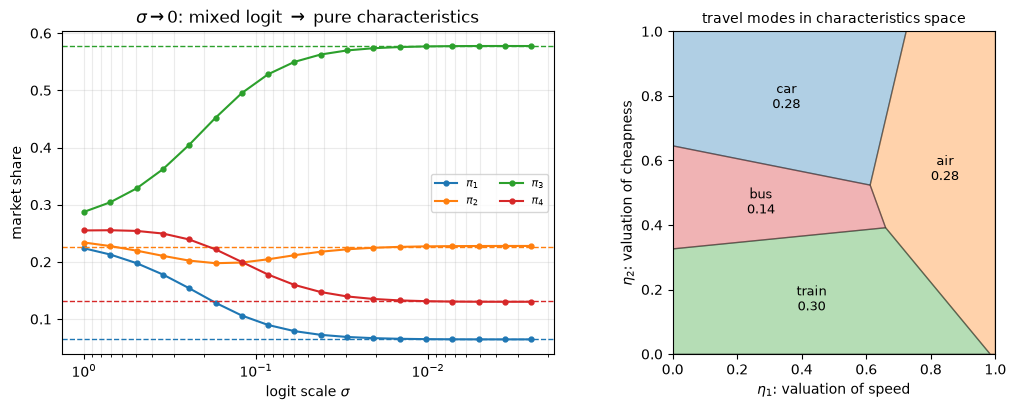

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

sig_grid = np.logspace(0, -2.6, 18)
paths = np.array([rcl_shares(U_base, nu_i_y, s) for s in sig_grid])
for y in range(Y):
    ax[0].semilogx(sig_grid, paths[:, y], 'o-', ms=3.5, color=f'C{y}',
                   label=rf'$\pi_{y+1}$')
    ax[0].axhline(pi_y[y], color=f'C{y}', ls='--', lw=1.0)
ax[0].set_xlabel(r'logit scale $\sigma$'); ax[0].set_ylabel('market share')
ax[0].set_title(r'$\sigma\to0$: mixed logit $\rightarrow$ pure characteristics')
ax[0].invert_xaxis(); ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.25, which='both')

draw_diagram(ax[1], U_tm, xi_tm, 'travel modes in characteristics space',
             labels=modes, show_sites=False)
ax[1].set_xlabel(r'$\eta_1$: valuation of speed')
ax[1].set_ylabel(r'$\eta_2$: valuation of cheapness')

plt.tight_layout(); plt.show()

*Left.* The simulated mixed-logit shares against $\sigma$, with the exact Laguerre areas as dashed lines. The convergence is monotone and fast; by $\sigma\approx0.01$ the two are indistinguishable at this resolution.

*Right.* The travel modes placed in characteristics space, with the Laguerre cells that rationalize the observed shares. A traveller is a point $(\eta_1,\eta_2)$ — how much they value speed, how much they value cheapness — and chooses the mode whose cell contains them. Adjacency is substitutability: the modes whose cells share a frontier are the ones between which travellers switch when a utility moves.

## Summing up

* **Options become locations.** The Lancasterian model replaces $Y$ free utilities by $Y$ points in an $M$-dimensional characteristics space, and substitution follows from adjacency. A new product is a new point, which is what makes counterfactuals possible at all.
* **The demand regions are Laguerre cells, and they can be computed exactly.** Clipping the square once per rival and applying the shoelace formulas gives areas and barycentres to machine precision — the book's three steps, vertex enumeration, triangulation and aggregation, in twenty lines and with no external geometry library. The areas summed to one to $10^{-16}$, and the welfare function assembled from eight geometric numbers matched a $2\times10^5$-draw simulation.
* **Inversion is semi-discrete optimal transport**, whose objective $\Psi(U)=\pi^\top U - G(U)$ is concave with gradient the residual demand $\pi-\pi(U)$. That turns the inverse problem into an unconstrained smooth maximization, solved here to eight decimals with no tuning.
* **The random coefficient logit is that transport problem, entropically regularized**, with $\sigma$ the regularization parameter. Verified end to end: dual value equals primal value, the coupling $\exp((\nu-u+U)/\sigma)$ has exactly the right marginals, and the recovered $U$ matches the generating one. As $\sigma\to0$ the simulated shares converge onto the exact cell areas — the same deletion of an entropy term from the dual that turned logistic regression into a linear program in lecture 4.
* **The economics: demand decomposes into who chooses what.** Inverting the travel-mode shares in characteristics space returns not only the utilities but the *barycentre of each cell* — the average valuation of speed and of cheapness among the people who chose that mode. No inversion in the earlier lectures could produce that, because no earlier lecture had a space for consumers to live in. It comes for free here, because the Laguerre diagram *is* the transport map from consumer types to products.

## Exercises

**1. (Proof — the welfare formula.)** Derive book equation (4.5), $G(U) = \sum_y\pi_y(U)(U_y+\xi_y^\top\bar\eta^y)$, from the definition of $G$, and show that $\nabla G(U) = \pi(U)$ follows — that is, verify Daly–Zachary–Williams directly in this model. Where does the fact that the cell boundaries move with $U$ fail to contribute a term, and why?

**2. (Proof — the power-diagram form.)** Show that the Laguerre cell (4.4) can be written as $\{\eta : |\eta-\xi_y/2|^2 - w_y \le |\eta-\xi_z/2|^2 - w_z\ \forall z\}$ with $w_y = U_y + |\xi_y|^2/4$, so that the diagram is a power diagram with sites $\xi_y/2$. Deduce that when all $|\xi_y|$ are equal the Laguerre diagram is an ordinary Voronoi diagram, and interpret that case economically.

**3. (Computation — dimension three.)** Extend `laguerre_cells` to $M=3$ by clipping a cube with half-spaces and computing polyhedron volumes and centroids. Verify against simulation, and time both. At what $M$ does exact computation stop being worth it, and how does that compare with the crossover for GHK found in lecture 5?

**4. (Computation — the transport map.)** For the travel-mode application of section 5, compute the optimal coupling explicitly: assign each of $I$ simulated $\eta_i$ to its cell, and verify that the resulting empirical coupling attains the transport value $-G^\ast(\pi)$ to within simulation error. Then re-solve with the entropic dual at several $\sigma$ and show that the coupling spreads: report the entropy $-\sum\lambda\log\lambda$ as a function of $\sigma$, and explain the trade-off it prices.

**5. (Economics — a new product.)** Introduce a fifth travel mode at a characteristics location of your choosing, with a systematic utility you must also choose. (i) Compute the new shares and identify which existing modes lose most, relating your answer to which cells the new one borders. (ii) Show that in the plain logit of lecture 2 the same entrant would take share in proportion to existing shares regardless of where you place it, and explain why the characteristics model does not. (iii) Lecture 7 makes the entrant's price endogenous. Conjecture how the diversion pattern changes when the incumbents can respond, and which dual variable measures the profit at stake.

---

### Run notes

`FAST_MODE = True` uses $2\times10^5$ draws for the simulation checks and $2\times10^4$ draws of $\eta$ for the mixed-logit experiments; `False` doubles both. Every assertion holds in both modes.

The book's listing `4-01` uses the `sdot` library of Hugo Leclerc and Quentin Mérigot for the Laguerre diagram. That is an additional dependency and would have to be installed separately, so this notebook implements the two-dimensional case directly: convex polygon clipping for vertex enumeration, and the shoelace formulas for area and centroid. The parameters of the geometry — $Y=4$, $M=2$, $\xi$ drawn with the legacy seed 800 — are the listing's own, so the diagram is the book's figure 4.1.

**Next:** lecture 7 makes characteristics endogenous. Prices are chosen by firms and correlate with unobserved quality, so the inversion of this notebook has to be embedded in an instrumental-variables GMM problem — the Berry–Levinsohn–Pakes method.